In [1]:
import pandas as pd
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor
from gluonts.dataset.repository.datasets import get_dataset
import matplotlib.pyplot as plt

c:\Users\rusha\miniconda3\envs\automl\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [25]:
# Load a dataset (example: "m4_hourly")
dataset_name = "m4_hourly"
dataset = get_dataset(dataset_name)

# Using the train and test presets
dataset_train = dataset.train
dataset_test = dataset.test

In [26]:
def process_dataset(dataset, metadata_freq):
    data_rows = []

    for entry in dataset:
        target_values = entry['target']
        start_date = entry['start'].to_timestamp()  # Convert Period to Timestamp
        item_id = entry.get('item_id', None)  # Handle missing 'item_id'
        date_range = pd.date_range(start=start_date, periods=len(target_values), freq=metadata_freq)

        for date, value in zip(date_range, target_values):
            data_rows.append({'date': date, 'value': value, 'item_id': item_id})

    return pd.DataFrame(data_rows)

# Process the datasets
df_train = process_dataset(dataset_train, dataset.metadata.freq)
df_test = process_dataset(dataset_test, dataset.metadata.freq)

# Display the first few rows of the DataFrames
print(df_train.head())
print(df_test.head())

                 date  value  item_id
0 1750-01-01 00:00:00  605.0        0
1 1750-01-01 01:00:00  586.0        0
2 1750-01-01 02:00:00  586.0        0
3 1750-01-01 03:00:00  559.0        0
4 1750-01-01 04:00:00  511.0        0
                 date  value  item_id
0 1750-01-01 00:00:00  605.0        0
1 1750-01-01 01:00:00  586.0        0
2 1750-01-01 02:00:00  586.0        0
3 1750-01-01 03:00:00  559.0        0
4 1750-01-01 04:00:00  511.0        0


In [27]:
# Save DataFrames as a pickled files
df_train.to_pickle("C:/Users/rusha/Desktop/pickled/df_train.pkl")
df_test.to_pickle("C:/Users/rusha/Desktop/pickled/df_test.pkl")

In [28]:
df_train

,date,value,item_id
0,1750-01-01 00:00:00,605.0,0
1,1750-01-01 01:00:00,586.0,0
2,1750-01-01 02:00:00,586.0,0
3,1750-01-01 03:00:00,559.0,0
4,1750-01-01 04:00:00,511.0,0
...,...,...,...
353495,1750-02-09 19:00:00,48.0,413
353496,1750-02-09 20:00:00,41.0,413
353497,1750-02-09 21:00:00,35.0,413
353498,1750-02-09 22:00:00,26.0,413


In [29]:
df_test

,date,value,item_id
0,1750-01-01 00:00:00,605.0,0
1,1750-01-01 01:00:00,586.0,0
2,1750-01-01 02:00:00,586.0,0
3,1750-01-01 03:00:00,559.0,0
4,1750-01-01 04:00:00,511.0,0
...,...,...,...
373367,1750-02-11 19:00:00,82.0,413
373368,1750-02-11 20:00:00,65.0,413
373369,1750-02-11 21:00:00,49.0,413
373370,1750-02-11 22:00:00,37.0,413


In [9]:
prediction_length = 24
df_sampled = df_train.iloc[::10]
data = TimeSeriesDataFrame.from_data_frame(
    df_sampled,#df for whole
    id_column="item_id",
    timestamp_column="date"
)

train_data1, test_data1 = data.train_test_split(prediction_length)


In [10]:
predictor = TimeSeriesPredictor(
    prediction_length=24,
    path="autogluon-m4-monthly",
    target="value",
    eval_metric="MASE",

)

predictor.fit(
    train_data1,
    presets="fast_training",
    time_limit=500,
    #excluded_model_types=["AutoETS", "AutoARIMA"],
)
predictor.evaluate(test_data1)

Beginning AutoGluon training... Time limit = 500s
AutoGluon will save models to 'autogluon-m4-monthly'


=================== System Info ===================
AutoGluon Version:  1.0.0
Python Version:     3.9.18
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.22621
CPU Count:          8
GPU Count:          0
Memory Avail:       0.63 GB / 7.44 GB (8.4%)
Disk Space Avail:   254.10 GB / 475.84 GB (53.4%)
Setting presets to: fast_training

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': MASE,
 'hyperparameters': 'very_light',
 'known_covariates_names': [],
 'num_val_windows': 1,
 'prediction_length': 24,
 'quantile_levels': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
 'random_seed': 123,
 'refit_every_n_windows': 1,
 'refit_full': False,
 'target': 'value',
 'time_limit': 500,
 'verbosity': 2}

Inferred time series frequency: '10H'
Provided train_data has 25414 rows, 414 time series. Median time series length is 72 (min=46, max=72). 
	Removing 169 short time series from train_data. Only series with length >= 49 will be used for training.
	Afte

{'MASE': -0.3935872600016558}

## Trying different parameters

In [41]:
from autogluon.common import space

predictor2 = TimeSeriesPredictor(
    prediction_length=24,
    path="autogluon-m4-monthly",
    target="value",
    eval_metric="MASE",
)

# predictor2.fit(
#     train_data1,
#     hyperparameters={
#         "DeepAR": {
#             "hidden_size": space.Int(20, 100),
#             "dropout_rate": space.Categorical(0.1, 0.3),
#         },
#     },
#     presets="fast_training",
#     time_limit=500,
#     #excluded_model_types=["AutoETS", "AutoARIMA"],
# )
# predictor2.evaluate(test_data1)

predictor3 = TimeSeriesPredictor(
    prediction_length=24,
    path="autogluon-m4-monthly",
    target="value",
    eval_metric="MASE",

)

predictor3.fit(
    train_data1,
     hyperparameters={
        "DeepAR": {},
        "ETS": [
            {"seasonal": "add"},
            {"seasonal": None},
        ],
     },
    presets="fast_training",
    time_limit=500,
    #excluded_model_types=["AutoETS", "AutoARIMA"],
)
predictor3.evaluate(test_data1)

# predictor4 = TimeSeriesPredictor(
#     prediction_length=24,
#     path="autogluon-m4-monthly",
#     target="value",
#     eval_metric="MASE",
# )

# predictor4.fit(
#     train_data1,
#     presets="fast_training",
#     time_limit=500,
#     #excluded_model_types=["AutoETS", "AutoARIMA"],
# )
# predictor4.evaluate(test_data1)


# predictor4.fit(
#     ...
#     hyperparameter_tune_kwargs={
#         "num_trials": 20,
#         "scheduler": "local",
#         "searcher": "random",
#     },
#     ...
# )

Beginning AutoGluon training... Time limit = 500s
AutoGluon will save models to 'autogluon-m4-monthly'
=================== System Info ===================
AutoGluon Version:  1.0.0
Python Version:     3.9.18
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.22621
CPU Count:          8
GPU Count:          0
Memory Avail:       0.98 GB / 7.44 GB (13.2%)
Disk Space Avail:   253.59 GB / 475.84 GB (53.3%)
Setting presets to: fast_training

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': MASE,
 'hyperparameters': {'DeepAR': {},
                     'ETS': [{'seasonal': 'add'}, {'seasonal': None}]},
 'known_covariates_names': [],
 'num_val_windows': 1,
 'prediction_length': 24,
 'quantile_levels': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
 'random_seed': 123,
 'refit_every_n_windows': 1,
 'refit_full': False,
 'target': 'value',
 'time_limit': 500,
 'verbosity': 2}

Inferred time series frequency: '10H'
Provided train_data has 25414 rows, 41

NetworkXError: The node RecursiveTabular is not in the digraph.

In [30]:
predictions1 = predictor.predict(train_data1)
predictions1.round(2)

Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble


mean     0.1     0.2     0.3     0.4     0.5  \
item_id timestamp                                                             
0       1750-01-20 04:00:00  623.63  484.32  532.14  566.63  596.09  623.63   
        1750-01-20 14:00:00  704.84  507.83  575.46  624.23  665.90  704.84   
        1750-01-21 00:00:00  829.16  587.86  670.69  730.42  781.46  829.16   
        1750-01-21 10:00:00  545.76  267.13  362.78  431.75  490.68  545.76   
        1750-01-21 20:00:00  897.05  585.54  692.47  769.58  835.47  897.05   
...                             ...     ...     ...     ...     ...     ...   
413     1750-02-07 22:00:00   15.04 -253.19 -161.11  -94.72  -37.99   15.04   
        1750-02-08 08:00:00  151.00 -123.85  -29.50   38.54   96.67  151.00   
        1750-02-08 18:00:00   66.65 -214.66 -118.09  -48.46   11.04   66.65   
        1750-02-09 04:00:00   31.92 -255.72 -156.98  -85.78  -24.94   31.92   
        1750-02-09 14:00:00  115.93 -177.90  -77.03   -4.30   57.84  115.93   

                                0.6      0.7      0.8      0.9  
item_id timestamp                                               
0       1750-01-20 04:00:00  651.17   680.64   715.12   762.95  
        1750-01-20 14:00:00  743.79   785.46   834.23   901.86  
        1750-01-21 00:00:00  876.86   927.90   987.62  1070.46  
        1750-01-21 10:00:00  600.84   659.77   728.74   824.38  
        1750-01-21 20:00:00  958.63  1024.52  1101.63  1208.56  
...                             ...      ...      ...      ...  
413     1750-02-07 22:00:00   68.06   124.79   191.19   283.26  
        1750-02-08 08:00:00  205.34   263.47   331.50   425.85  
        1750-02-08 18:00:00  122.27   181.77   251.40   347.97  
        1750-02-09 04:00:00   88.79   149.62   220.82   319.56  
        1750-02-09 14:00:00  174.02   236.16   308.89   409.75  

[9936 rows x 10 columns]

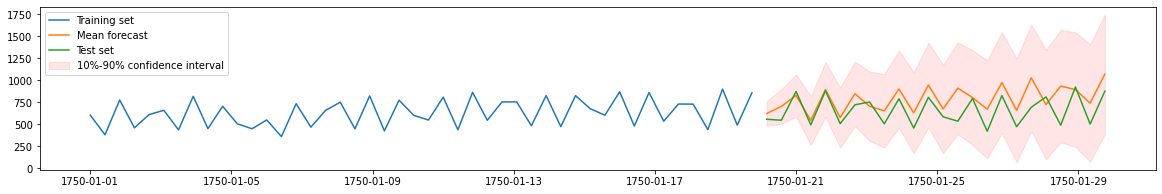

In [31]:
plt.figure(figsize=(20, 3))
item_id = 0
#get last timestamp
last_train_timestamp = train_data1.loc[item_id].index[-1]

# Slice the training data up to the last timestamp
y_past = train_data1.loc[item_id]["value"]
y_pred = predictions1.loc[item_id]
y_test = test_data1.loc[item_id]["value"][-24:]

plt.plot(y_past, label="Training set")
plt.plot(y_pred["mean"], label="Mean forecast")
plt.plot(y_test, label="Test set")

plt.fill_between(
    y_pred.index, y_pred["0.1"], y_pred["0.9"], color="red", alpha=0.1, label=f"10%-90% confidence interval"
)
plt.legend();

In [15]:
predictions = predictor.predict(test_data1)
predictions.round(2)

Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble


mean     0.1     0.2     0.3     0.4     0.5  \
item_id timestamp                                                             
0       1750-01-30 04:00:00  637.90  495.86  544.62  579.78  609.82  637.90   
        1750-01-30 14:00:00  698.41  497.53  566.49  616.21  658.70  698.41   
        1750-01-31 00:00:00  834.05  588.03  672.48  733.38  785.41  834.05   
        1750-01-31 10:00:00  527.59  243.51  341.03  411.35  471.43  527.59   
        1750-01-31 20:00:00  890.67  573.06  682.09  760.71  827.88  890.67   
...                             ...     ...     ...     ...     ...     ...   
413     1750-02-17 22:00:00   70.39 -194.36 -103.48  -37.94   18.05   70.39   
        1750-02-18 08:00:00  184.32  -86.97    6.16   73.31  130.69  184.32   
        1750-02-18 18:00:00  144.93 -132.75  -37.43   31.30   90.03  144.93   
        1750-02-19 04:00:00   58.15 -225.76 -128.30  -58.02    2.03   58.15   
        1750-02-19 14:00:00  159.13 -130.89  -31.34   40.45  101.79  159.13   

                                0.6      0.7      0.8      0.9  
item_id timestamp                                               
0       1750-01-30 04:00:00  665.98   696.02   731.18   779.94  
        1750-01-30 14:00:00  738.12   780.61   830.33   899.28  
        1750-01-31 00:00:00  882.68   934.72   995.61  1080.07  
        1750-01-31 10:00:00  583.75   643.84   714.15   811.67  
        1750-01-31 20:00:00  953.46  1020.63  1099.25  1208.28  
...                             ...      ...      ...      ...  
413     1750-02-17 22:00:00  122.73   178.72   244.26   335.14  
        1750-02-18 08:00:00  237.96   295.33   362.49   455.61  
        1750-02-18 18:00:00  199.82   258.55   327.28   422.60  
        1750-02-19 04:00:00  114.28   174.33   244.61   342.07  
        1750-02-19 14:00:00  216.46   277.80   349.59   449.15  

[9936 rows x 10 columns]

In [17]:
df_subsampled_train = df_train.iloc[::10]
df_subsampled_test = df_test.iloc[::10]
train_data = TimeSeriesDataFrame.from_data_frame(
    df_subsampled_train,#df for whole
    id_column="item_id",
    timestamp_column="date"
)
train_data

test_data = TimeSeriesDataFrame.from_data_frame(
    df_subsampled_test,#df for whole
    id_column="item_id",
    timestamp_column="date"
)
test_data

print(len(df_subsampled_train))
print(len(df_subsampled_test))

35350
37338


In [18]:
# Saving the DataFrames to pickle files
train_data.to_pickle("C:/Users/rusha/Desktop/pickled/train_data.pkl")
test_data.to_pickle("C:/Users/rusha/Desktop/pickled/test_data.pkl")

In [19]:
# Loading the DataFrames from pickle files
train_data = pd.read_pickle("C:/Users/rusha/Desktop/pickled/train_data.pkl")
test_data = pd.read_pickle("C:/Users/rusha/Desktop/pickled/test_data.pkl")

In [20]:
train_data.index

MultiIndex([(  0, '1750-01-01 00:00:00'),
            (  0, '1750-01-01 10:00:00'),
            (  0, '1750-01-01 20:00:00'),
            (  0, '1750-01-02 06:00:00'),
            (  0, '1750-01-02 16:00:00'),
            (  0, '1750-01-03 02:00:00'),
            (  0, '1750-01-03 12:00:00'),
            (  0, '1750-01-03 22:00:00'),
            (  0, '1750-01-04 08:00:00'),
            (  0, '1750-01-04 18:00:00'),
            ...
            (413, '1750-02-05 20:00:00'),
            (413, '1750-02-06 06:00:00'),
            (413, '1750-02-06 16:00:00'),
            (413, '1750-02-07 02:00:00'),
            (413, '1750-02-07 12:00:00'),
            (413, '1750-02-07 22:00:00'),
            (413, '1750-02-08 08:00:00'),
            (413, '1750-02-08 18:00:00'),
            (413, '1750-02-09 04:00:00'),
            (413, '1750-02-09 14:00:00')],
           names=['item_id', 'timestamp'], length=35350)

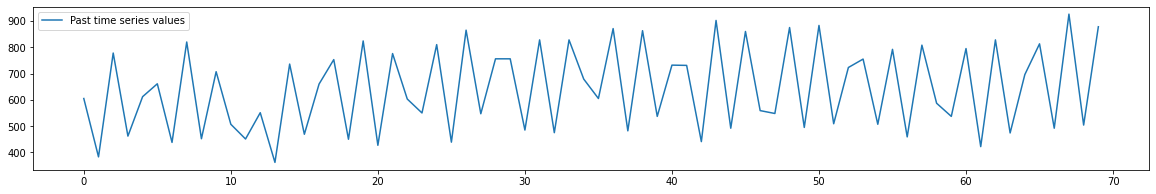

In [21]:
import matplotlib.pyplot as plt

item_id = 0  # Assuming item_id is an integer
y_past = train_data.loc[item_id,'value'].reset_index(drop=True)
y_test = test_data.loc[(item_id, slice(None)), 'value'].reset_index(drop=True)
# Plotting
plt.figure(figsize=(20, 3))
plt.plot(y_past, label="Past time series values")
#plt.plot(y_test, label="TEST time series values")
plt.legend()
plt.show()

In [22]:
'''This means, 
at least some time series in train_data must have length >= max(prediction_length + 1, 5) + prediction_length 
when training with default settings
>= max(prediction_length + 1, 5) + prediction_length + (num_val_windows - 1) * val_step_size. 
This will reduce the likelihood of overfitting but will increase the training time approximately by a factor of num_val_windows. 
Num_val_windows Note that multiple validation windows can only be used if the time series in train_data have length of at least (num_val_windows + 1) * prediction_length
'''
predictor = TimeSeriesPredictor(
    prediction_length=24,
    path="autogluon-m4-monthly",
    target="value",
    eval_metric="MASE",

)

predictor.fit(
    train_data,
    presets="fast_training",
    time_limit=500,
    #excluded_model_types=["AutoETS", "AutoARIMA"],
)


Beginning AutoGluon training... Time limit = 500s
AutoGluon will save models to 'autogluon-m4-monthly'
=================== System Info ===================
AutoGluon Version:  1.0.0
Python Version:     3.9.18
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.22621
CPU Count:          8
GPU Count:          0
Memory Avail:       0.94 GB / 7.44 GB (12.6%)
Disk Space Avail:   254.07 GB / 475.84 GB (53.4%)
Setting presets to: fast_training

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': MASE,
 'hyperparameters': 'very_light',
 'known_covariates_names': [],
 'num_val_windows': 1,
 'prediction_length': 24,
 'quantile_levels': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
 'random_seed': 123,
 'refit_every_n_windows': 1,
 'refit_full': False,
 'target': 'value',
 'time_limit': 500,
 'verbosity': 2}

Inferred time series frequency: '10H'
Provided train_data has 35350 rows, 414 time series. Median time series length is 96 (min=70, max=96). 

Provid

In [23]:
predictions = predictor.predict(train_data)
predictions.round(2)
#MISSING EVALUATION HERE?!
#WITH BACKTEST WE CAN MAKE EVALUATION BETTER? MAKE BOTH AND THEN VERGLEICHE(only if traindata is long? at what number is it long??)


Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble


mean     0.1     0.2     0.3     0.4     0.5  \
item_id timestamp                                                             
0       1750-01-30 04:00:00  637.90  495.86  544.62  579.78  609.82  637.90   
        1750-01-30 14:00:00  698.41  497.53  566.49  616.21  658.70  698.41   
        1750-01-31 00:00:00  834.05  588.03  672.48  733.38  785.41  834.05   
        1750-01-31 10:00:00  527.59  243.51  341.03  411.35  471.43  527.59   
        1750-01-31 20:00:00  890.67  573.06  682.09  760.71  827.88  890.67   
...                             ...     ...     ...     ...     ...     ...   
413     1750-02-17 22:00:00   70.39 -194.36 -103.48  -37.94   18.05   70.39   
        1750-02-18 08:00:00  184.32  -86.97    6.16   73.31  130.69  184.32   
        1750-02-18 18:00:00  144.93 -132.75  -37.43   31.30   90.03  144.93   
        1750-02-19 04:00:00   58.15 -225.76 -128.30  -58.02    2.03   58.15   
        1750-02-19 14:00:00  159.13 -130.89  -31.34   40.45  101.79  159.13   

                                0.6      0.7      0.8      0.9  
item_id timestamp                                               
0       1750-01-30 04:00:00  665.98   696.02   731.18   779.94  
        1750-01-30 14:00:00  738.12   780.61   830.33   899.28  
        1750-01-31 00:00:00  882.68   934.72   995.61  1080.07  
        1750-01-31 10:00:00  583.75   643.84   714.15   811.67  
        1750-01-31 20:00:00  953.46  1020.63  1099.25  1208.28  
...                             ...      ...      ...      ...  
413     1750-02-17 22:00:00  122.73   178.72   244.26   335.14  
        1750-02-18 08:00:00  237.96   295.33   362.49   455.61  
        1750-02-18 18:00:00  199.82   258.55   327.28   422.60  
        1750-02-19 04:00:00  114.28   174.33   244.61   342.07  
        1750-02-19 14:00:00  216.46   277.80   349.59   449.15  

[9936 rows x 10 columns]

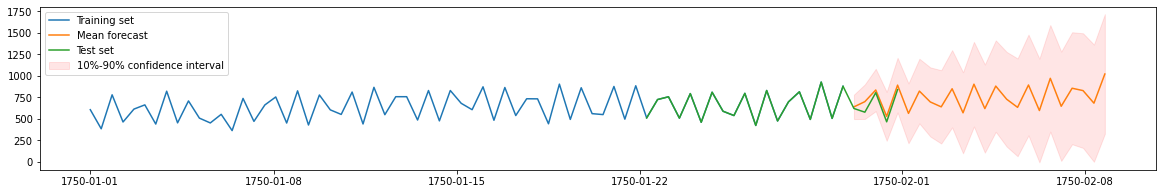

In [24]:
plt.figure(figsize=(20, 3))
item_id = 0
#get last timestamp
last_train_timestamp = train_data.loc[item_id].index[-1]

# Slice the training data up to the last timestamp
y_past = train_data.loc[item_id][:last_train_timestamp]["value"]
y_pred = predictions.loc[item_id]
y_test = test_data.loc[item_id]["value"][-24:]
#y_past = train_data.loc[item_id].loc[:last_train_timestamp, 'value'].reset_index(drop=True)
#print(y_past)
#y_past = train_data.loc[(item_id, slice(None)), 'value'][:-68].reset_index(drop=True)
#y_test = test_data.loc[(item_id, slice(None)), 'value'][-24:].reset_index(drop=True)

#y_test = test_data.loc[item_id].loc[:last_train_timestamp, 'value'].reset_index(drop=True)
#print(y_test)
#y_pred = predictions.loc[item_id].reset_index(drop=True)


plt.plot(y_past, label="Training set")
plt.plot(y_pred["mean"], label="Mean forecast")
plt.plot(y_test, label="Test set")

plt.fill_between(
    y_pred.index, y_pred["0.1"], y_pred["0.9"], color="red", alpha=0.1, label=f"10%-90% confidence interval"
)
plt.legend();

In [96]:
# Check the last timestamp of the training data
print("Last training timestamp:", last_train_timestamp)

# Check the range of the test data
print("Test data timestamps:", test_data.loc[item_id].index)

# Check the range of the predictions
print("Prediction timestamps:", predictions.loc[item_id].index)


Last training timestamp: 1750-01-29 18:00:00
Test data timestamps: DatetimeIndex(['1750-01-01 00:00:00', '1750-01-01 10:00:00',
               '1750-01-01 20:00:00', '1750-01-02 06:00:00',
               '1750-01-02 16:00:00', '1750-01-03 02:00:00',
               '1750-01-03 12:00:00', '1750-01-03 22:00:00',
               '1750-01-04 08:00:00', '1750-01-04 18:00:00',
               '1750-01-05 04:00:00', '1750-01-05 14:00:00',
               '1750-01-06 00:00:00', '1750-01-06 10:00:00',
               '1750-01-06 20:00:00', '1750-01-07 06:00:00',
               '1750-01-07 16:00:00', '1750-01-08 02:00:00',
               '1750-01-08 12:00:00', '1750-01-08 22:00:00',
               '1750-01-09 08:00:00', '1750-01-09 18:00:00',
               '1750-01-10 04:00:00', '1750-01-10 14:00:00',
               '1750-01-11 00:00:00', '1750-01-11 10:00:00',
               '1750-01-11 20:00:00', '1750-01-12 06:00:00',
               '1750-01-12 16:00:00', '1750-01-13 02:00:00',
               '17

In [157]:
last_train_date = train_data.index.get_level_values('timestamp')[-27]
print(last_train_date)
y_past = train_data1.loc[(item_id, slice(None)), 'value']
print(len(y_past))

1750-01-24 04:00:00
46


In [41]:
last_train_timestamp = train_data.loc[item_id].index[-1]
last_train_timestamp

Timestamp('1750-01-29 18:00:00')

In [49]:
last_train_timestamp = train_data.loc[item_id].index[-1]

# Slice the training data up to the last timestamp
y_past = train_data.loc[item_id].loc[:last_train_timestamp, 'value'].reset_index(drop=True)
y_past

0     605.0
1     383.0
2     778.0
3     462.0
4     612.0
      ...  
65    813.0
66    492.0
67    926.0
68    504.0
69    878.0
Name: value, Length: 70, dtype: float32

In [85]:
y_test = test_data.loc[item_id].loc[:last_train_timestamp, 'value'].reset_index(drop=True)
y_test

0     605.0
1     383.0
2     778.0
3     462.0
4     612.0
      ...  
65    813.0
66    492.0
67    926.0
68    504.0
69    878.0
Name: value, Length: 70, dtype: float32

In [52]:
print(train_data.columns)
print(test_data.columns)
print(predictions.columns)
print(df_train.columns)


Index(['value'], dtype='object')
Index(['value'], dtype='object')
Index(['mean', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9'], dtype='object')
Index(['date', 'value', 'item_id'], dtype='object')
